# Home Credit Default Risk: Exploratory Data Analysis

Notebook 1 of 5 in a chained pipeline: EDA, feature engineering, tuning, training, then explainability and scorecard. This notebook studies the raw data and motivates the feature engineering in notebook 2. Nothing it computes is consumed downstream.

The data has 307,511 labelled loan applications and six tables of credit history: bureau records from other lenders and their monthly balances, previous Home Credit applications, POS and cash loan balances, credit card balances, and instalment payments.

## Setup

Imports, plotting style and two helpers. `find_file` searches the Kaggle input folder so the notebook does not depend on how Kaggle mounts the competition data. `save` writes every figure to `figures/` in the output.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.width", 160)


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()


print(f"application file found at {find_file('application_train.csv')}")

application file found at /kaggle/input/competitions/home-credit-default-risk/application_train.csv


**Conclusion.** The competition data is mounted under `/kaggle/input/competitions/home-credit-default-risk/`, and `find_file` located it without a hard-coded path, so later notebooks can use the same helper.

## Load the seven tables

Aim: confirm the applicant count behind the 307K figure, and record the size, memory footprint and overall missingness of every table before any analysis.

In [2]:
TABLES = {
    "application_train": "application_train.csv",
    "bureau": "bureau.csv",
    "bureau_balance": "bureau_balance.csv",
    "previous_application": "previous_application.csv",
    "POS_CASH_balance": "POS_CASH_balance.csv",
    "credit_card_balance": "credit_card_balance.csv",
    "installments_payments": "installments_payments.csv",
}
dfs = {name: pd.read_csv(find_file(file)) for name, file in TABLES.items()}
overview = pd.DataFrame(
    {
        "rows": {k: len(v) for k, v in dfs.items()},
        "columns": {k: v.shape[1] for k, v in dfs.items()},
        "memory_mb": {k: round(v.memory_usage(deep=True).sum() / 1e6, 1) for k, v in dfs.items()},
        "missing_cells_pct": {k: round(100 * v.isna().to_numpy().mean(), 2) for k, v in dfs.items()},
    }
)
print(overview.to_string())
app = dfs["application_train"]

                           rows  columns  memory_mb  missing_cells_pct
application_train        307511      122      529.5              24.40
bureau                  1716428       17      495.8              13.50
bureau_balance         27299925        3     1801.8               0.00
previous_application    1670214       37     1785.7              17.98
POS_CASH_balance       10001358        8     1112.5               0.07
credit_card_balance     3840312       23      887.5               6.65
installments_payments  13605401        8      870.7               0.01


**Conclusion.** All seven tables loaded. `application_train` has 307,511 rows and 122 columns: this is the applicant population the project reports on. The history tables are far larger, with 27.3 million monthly bureau balance rows, 13.6 million instalment payments and 10.0 million POS and cash balance rows. Together the tables take about 7.5 GB in memory, so notebook 2 aggregates each history table and releases it before loading the next. A quarter of the application cells (24.4%) are missing, against almost none in the payment tables.

## Target balance

Aim: measure how rare defaults are. The answer decides the metric: with a heavily imbalanced target, accuracy is meaningless and ranking metrics such as AUC are the right yardstick.

TARGET
0    282686
1     24825
default rate 0.0807, accuracy of always predicting repayment 0.9193


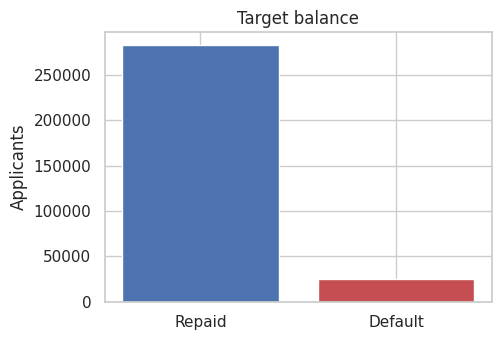

In [3]:
counts = app["TARGET"].value_counts().sort_index()
rate = app["TARGET"].mean()
print(counts.to_string())
print(f"default rate {rate:.4f}, accuracy of always predicting repayment {1 - rate:.4f}")
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["Repaid", "Default"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Applicants")
ax.set_title("Target balance")
save(fig, "01_target_balance")

**Conclusion.** 282,686 applicants repaid and 24,825 defaulted, a default rate of 8.07%. A model that always predicts repayment would be 91.93% accurate while catching no defaulter, so accuracy is useless here. The project judges models by AUC, which measures how well defaulters are ranked above payers, and adds PR-AUC and the Brier score to cover the minority class and calibration.

## Missing values in the application table

Aim: find which application fields are sparse. Gradient boosting handles missing values natively, so the question is whether missingness itself carries signal rather than whether to impute.

columns with any missing value: 67 of 122
columns more than half missing: 41
COMMONAREA_AVG              0.699
COMMONAREA_MODE             0.699
COMMONAREA_MEDI             0.699
NONLIVINGAPARTMENTS_MEDI    0.694
NONLIVINGAPARTMENTS_MODE    0.694
NONLIVINGAPARTMENTS_AVG     0.694
FONDKAPREMONT_MODE          0.684
LIVINGAPARTMENTS_AVG        0.684
LIVINGAPARTMENTS_MEDI       0.684
LIVINGAPARTMENTS_MODE       0.684
FLOORSMIN_MODE              0.678
FLOORSMIN_AVG               0.678
FLOORSMIN_MEDI              0.678
YEARS_BUILD_AVG             0.665
YEARS_BUILD_MODE            0.665
YEARS_BUILD_MEDI            0.665
OWN_CAR_AGE                 0.660
LANDAREA_MEDI               0.594
LANDAREA_AVG                0.594
LANDAREA_MODE               0.594


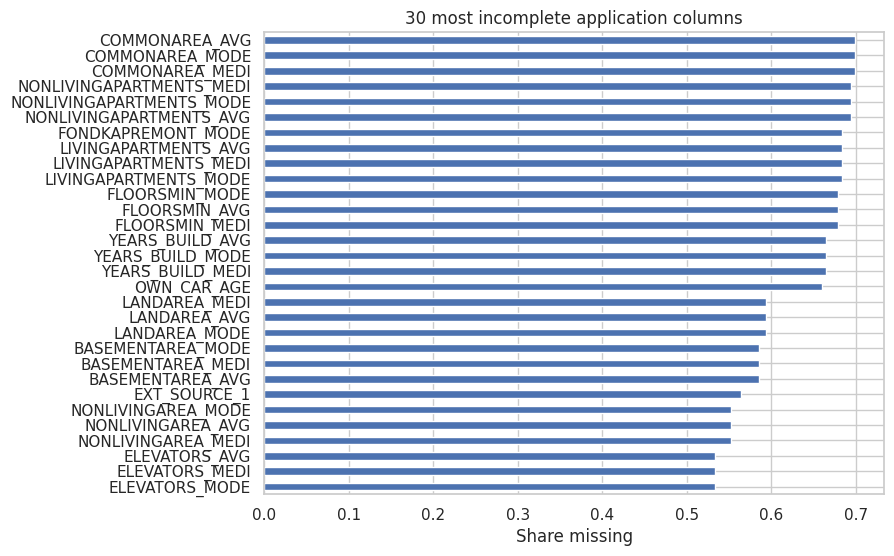

In [4]:
missing = app.isna().mean().sort_values(ascending=False)
print(f"columns with any missing value: {(missing > 0).sum()} of {app.shape[1]}")
print(f"columns more than half missing: {(missing > 0.5).sum()}")
print(missing.head(20).round(3).to_string())
fig, ax = plt.subplots(figsize=(8, 6))
missing.head(30).iloc[::-1].plot.barh(ax=ax)
ax.set_xlabel("Share missing")
ax.set_title("30 most incomplete application columns")
save(fig, "02_missing_application")

**Conclusion.** 67 of the 122 columns have gaps and 41 are more than half missing. The worst are building descriptors (COMMONAREA, NONLIVINGAPARTMENTS, LIVINGAPARTMENTS, FLOORSMIN, YEARS_BUILD), each 66% to 70% missing, along with OWN_CAR_AGE at 66%. These columns are kept as they are: LightGBM and XGBoost send missing values down whichever branch reduces loss, so missingness can act as a signal instead of being imputed away.

## The DAYS_EMPLOYED anomaly

Aim: inspect the placeholder value 365243 (about 1,000 years of employment), see which applicants carry it and whether their default rate differs, to decide between dropping, imputing or flagging it.

rows with DAYS_EMPLOYED = 365243: 55,374 (18.01%)
default rate with anomaly 0.0540, without 0.0866
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22


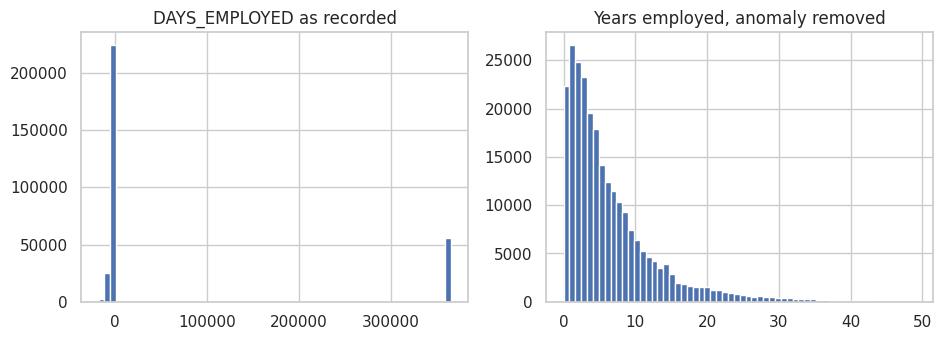

In [5]:
anomaly = app["DAYS_EMPLOYED"] == 365243
print(f"rows with DAYS_EMPLOYED = 365243: {anomaly.sum():,} ({anomaly.mean():.2%})")
print(f"default rate with anomaly {app.loc[anomaly, 'TARGET'].mean():.4f}, without {app.loc[~anomaly, 'TARGET'].mean():.4f}")
print(app.loc[anomaly, "NAME_INCOME_TYPE"].value_counts().to_string())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(app["DAYS_EMPLOYED"], bins=60)
axes[0].set_title("DAYS_EMPLOYED as recorded")
axes[1].hist(-app.loc[~anomaly, "DAYS_EMPLOYED"] / 365, bins=60)
axes[1].set_title("Years employed, anomaly removed")
save(fig, "03_days_employed")

**Conclusion.** 55,374 applicants (18.01%) carry the 365243 placeholder, and 55,352 of them are pensioners, so the value means "not employed" rather than a real duration. Their default rate is 5.40% against 8.66% for everyone else, so the placeholder carries real information. Notebook 2 replaces it with a missing value and adds a separate flag, which keeps the signal without distorting the employment-length scale. With the placeholder removed, years employed is right-skewed and most applicants have under 10 years.

## Age, income and credit amount

Aim: check the scale and skew of the core amounts and whether age separates defaulters from payers, which guides the ratio features built in notebook 2.

count    307511.0
mean         43.9
std          12.0
min          20.5
25%          34.0
50%          43.2
75%          53.9
max          69.1
AMT_INCOME_TOTAL: median 147,150, 99th percentile 472,500, max 117,000,000
AMT_CREDIT: median 513,531, 99th percentile 1,854,000, max 4,050,000
AMT_ANNUITY: median 24,903, 99th percentile 70,006, max 258,026
AMT_GOODS_PRICE: median 450,000, 99th percentile 1,800,000, max 4,050,000


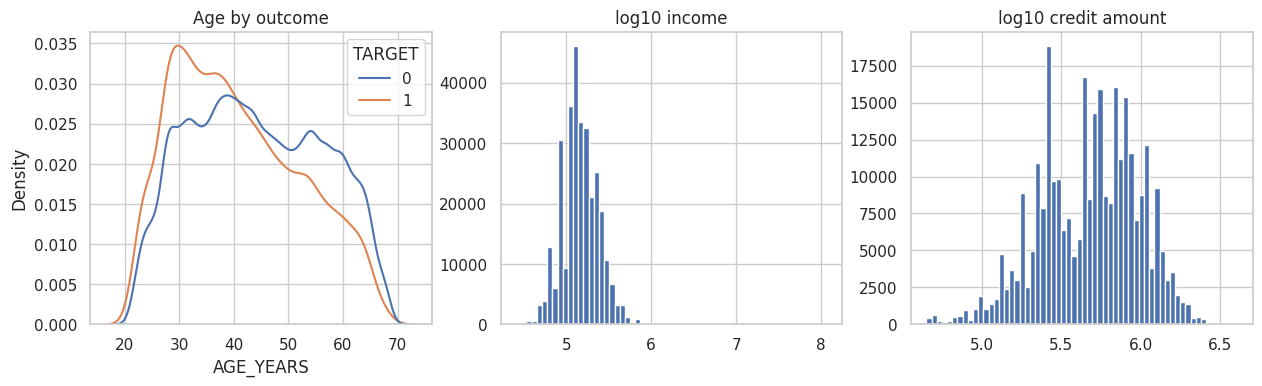

In [6]:
app["AGE_YEARS"] = -app["DAYS_BIRTH"] / 365
print(app["AGE_YEARS"].describe().round(1).to_string())
for col in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]:
    q = app[col].quantile([0.5, 0.99, 1.0])
    print(f"{col}: median {q[0.5]:,.0f}, 99th percentile {q[0.99]:,.0f}, max {q[1.0]:,.0f}")
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
sns.kdeplot(data=app, x="AGE_YEARS", hue="TARGET", common_norm=False, ax=axes[0])
axes[0].set_title("Age by outcome")
axes[1].hist(np.log10(app["AMT_INCOME_TOTAL"]), bins=60)
axes[1].set_title("log10 income")
axes[2].hist(np.log10(app["AMT_CREDIT"]), bins=60)
axes[2].set_title("log10 credit amount")
save(fig, "04_age_income_credit")

**Conclusion.** Applicants are 20.5 to 69.1 years old with a median of 43.2. Defaulters skew young: their age density peaks near 30, while payers spread evenly into their mid 60s. Income is heavily skewed, with a median of 147,150 but a maximum of 117,000,000, about 250 times the 99th percentile, and credit amounts cluster at round values. Because raw amounts are skewed and move together, notebook 2 relies on ratios such as credit to annuity and annuity to income rather than raw amounts alone.

## Default rate by segment

Aim: compare default rates across the six segments the Basel scorecard will report on (contract type, income type, education, family status, region rating, age band), to confirm they are meaningfully different populations.


NAME_CONTRACT_TYPE
                     count    mean
NAME_CONTRACT_TYPE                
Revolving loans      29279  0.0548
Cash loans          278232  0.0835

NAME_INCOME_TYPE
                       count    mean
NAME_INCOME_TYPE                    
Businessman               10  0.0000
Student                   18  0.0000
Pensioner              55362  0.0539
State servant          21703  0.0575
Commercial associate   71617  0.0748
Working               158774  0.0959
Unemployed                22  0.3636
Maternity leave            5  0.4000

NAME_EDUCATION_TYPE
                                count    mean
NAME_EDUCATION_TYPE                          
Academic degree                   164  0.0183
Higher education                74863  0.0536
Incomplete higher               10277  0.0848
Secondary / secondary special  218391  0.0894
Lower secondary                  3816  0.1093

NAME_FAMILY_STATUS
                       count    mean
NAME_FAMILY_STATUS                  
Unknown        

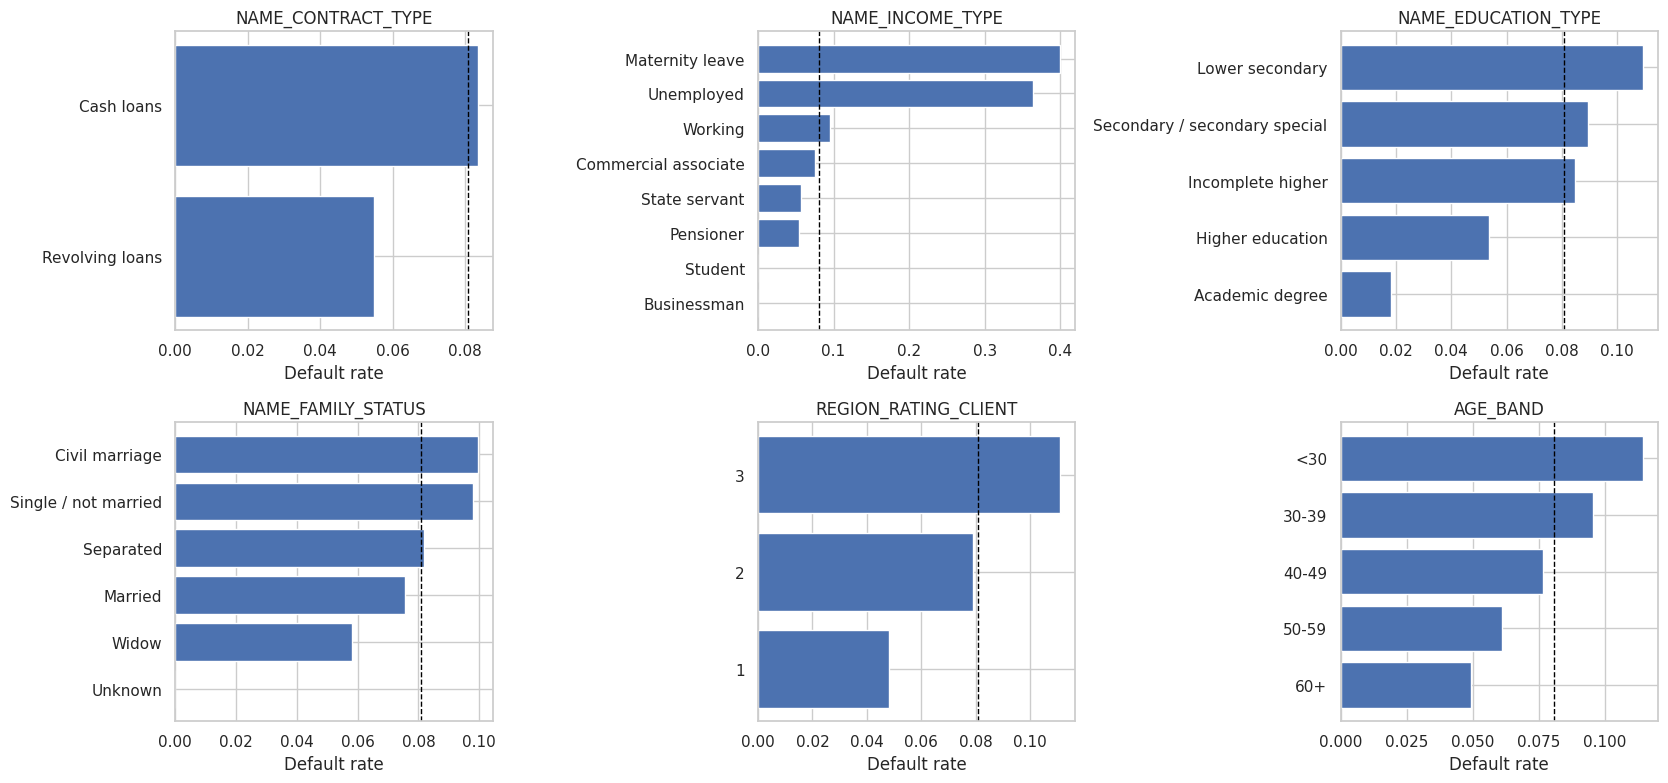

In [7]:
app["AGE_BAND"] = pd.cut(app["AGE_YEARS"], bins=[0, 30, 40, 50, 60, 120], right=False, labels=["<30", "30-39", "40-49", "50-59", "60+"])
SEGMENTS = ["NAME_CONTRACT_TYPE", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "REGION_RATING_CLIENT", "AGE_BAND"]
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, seg in zip(axes.ravel(), SEGMENTS):
    stats = app.groupby(seg, observed=True)["TARGET"].agg(["count", "mean"]).sort_values("mean")
    print(f"\n{seg}\n{stats.round(4).to_string()}")
    ax.barh(stats.index.astype(str), stats["mean"])
    ax.axvline(rate, color="black", linestyle="--", linewidth=1)
    ax.set_title(seg)
    ax.set_xlabel("Default rate")
fig.tight_layout()
save(fig, "05_default_rate_by_segment")

**Conclusion.** Every segment separates default rates. Cash loans default at 8.35% against 5.48% for revolving loans. Working applicants default at 9.59% against 5.39% for pensioners; the extreme rates for the unemployed (36.4%) and maternity leave (40.0%) rest on only 22 and 5 applicants. Education runs from 1.83% for an academic degree to 10.93% for lower secondary, region rating from 4.82% (rating 1) to 11.10% (rating 3), and age bands fall steadily from 11.46% under 30 to 4.92% at 60 and over. These are the six segments the scorecard reports capital for in notebook 5.

## External credit scores

Aim: measure how strongly the three external scores relate to default and how often each is missing, since combinations of them are candidate features.

EXT_SOURCE_1   -0.1553
EXT_SOURCE_2   -0.1605
EXT_SOURCE_3   -0.1789
TARGET          1.0000
EXT_SOURCE_1: missing 0.564, default rate when missing 0.0852, when present 0.0750
EXT_SOURCE_2: missing 0.002, default rate when missing 0.0788, when present 0.0807
EXT_SOURCE_3: missing 0.198, default rate when missing 0.0931, when present 0.0777


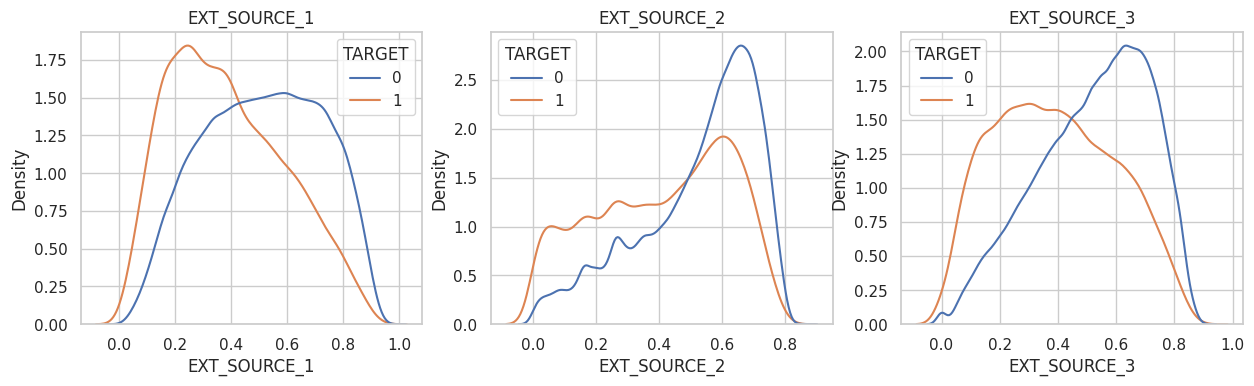

In [8]:
ext = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
print(app[ext + ["TARGET"]].corr()["TARGET"].round(4).to_string())
for col in ext:
    present = app[col].notna()
    print(f"{col}: missing {1 - present.mean():.3f}, default rate when missing {app.loc[~present, 'TARGET'].mean():.4f}, when present {app.loc[present, 'TARGET'].mean():.4f}")
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col in zip(axes, ext):
    sns.kdeplot(data=app, x=col, hue="TARGET", common_norm=False, ax=ax)
    ax.set_title(col)
save(fig, "06_ext_source")

**Conclusion.** All three external scores correlate negatively with default (-0.155, -0.161 and -0.179 for sources 1, 2 and 3), and their densities show defaulters concentrated at low scores. Coverage differs sharply: EXT_SOURCE_1 is missing for 56.4% of applicants, EXT_SOURCE_3 for 19.8% and EXT_SOURCE_2 for only 0.2%. A missing source 3 raises the default rate from 7.77% to 9.31%. Each score is strong but incomplete, so notebook 2 combines them (mean, minimum, maximum, product and a weighted sum) to give every applicant a usable composite.

## Linear correlation with the target

Aim: rank numeric application fields by Pearson correlation with default. This is a coarse screen; tree models will capture non-linear effects this misses.

most negative:
EXT_SOURCE_3                 -0.1789
EXT_SOURCE_2                 -0.1605
EXT_SOURCE_1                 -0.1553
DAYS_EMPLOYED                -0.0449
FLOORSMAX_AVG                -0.0440
FLOORSMAX_MEDI               -0.0438
FLOORSMAX_MODE               -0.0432
AMT_GOODS_PRICE              -0.0396
REGION_POPULATION_RELATIVE   -0.0372
ELEVATORS_AVG                -0.0342
most positive:
DAYS_REGISTRATION              0.0420
FLAG_DOCUMENT_3                0.0443
REG_CITY_NOT_LIVE_CITY         0.0444
FLAG_EMP_PHONE                 0.0460
REG_CITY_NOT_WORK_CITY         0.0510
DAYS_ID_PUBLISH                0.0515
DAYS_LAST_PHONE_CHANGE         0.0552
REGION_RATING_CLIENT           0.0589
REGION_RATING_CLIENT_W_CITY    0.0609
DAYS_BIRTH                     0.0782


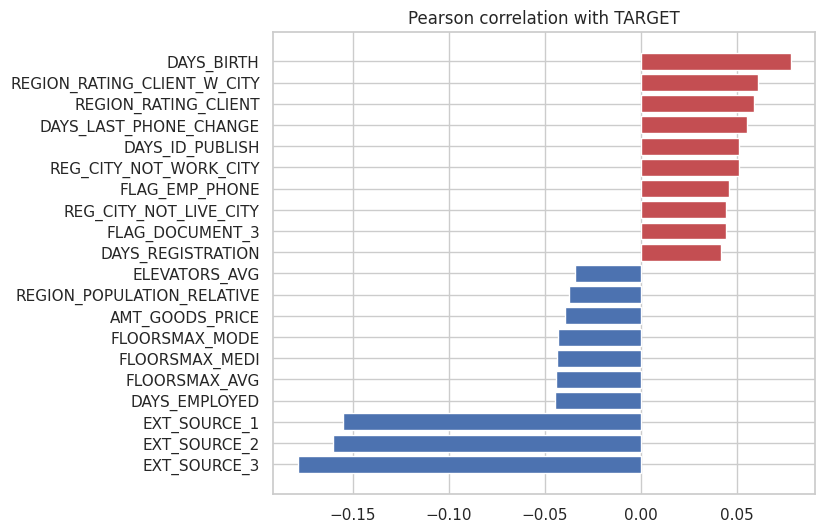

In [9]:
numeric = app.select_dtypes("number").drop(columns=["SK_ID_CURR", "TARGET", "AGE_YEARS"])
corr = numeric.corrwith(app["TARGET"]).dropna().sort_values()
print("most negative:\n" + corr.head(10).round(4).to_string())
print("most positive:\n" + corr.tail(10).round(4).to_string())
top = pd.concat([corr.head(10), corr.tail(10)])
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color=np.where(top.values < 0, "#4C72B0", "#C44E52"))
ax.set_title("Pearson correlation with TARGET")
save(fig, "07_target_correlation")

**Conclusion.** The external scores dominate this linear screen. The next strongest field, DAYS_BIRTH, reaches only 0.078: younger applicants, whose DAYS_BIRTH is closer to zero, default more. Region ratings, recent phone and ID changes, and mismatches between registration, living and work cities follow, all below 0.07. DAYS_EMPLOYED shows only -0.045 because the 365243 placeholder distorts it. Weak linear correlations do not rule out signal; the tree models in notebooks 3 and 4 can use non-linear effects and interactions.

## Composition of the history tables

Aim: understand the categorical states in the history tables (active versus closed bureau loans, monthly bureau status codes, approved versus refused applications, POS contract status), which define the splits used in aggregation.


bureau CREDIT_ACTIVE
CREDIT_ACTIVE
Closed      0.6288
Active      0.3674
Sold        0.0038
Bad debt    0.0000

bureau_balance STATUS
STATUS
C    0.4999
0    0.2747
X    0.2128
1    0.0089
5    0.0023
2    0.0009
3    0.0003
4    0.0002

previous NAME_CONTRACT_STATUS
NAME_CONTRACT_STATUS
Approved        0.6207
Canceled        0.1894
Refused         0.1740
Unused offer    0.0158

POS NAME_CONTRACT_STATUS
NAME_CONTRACT_STATUS
Active                   0.9150
Completed                0.0745
Signed                   0.0087
Demand                   0.0007
Returned to the store    0.0005
Approved                 0.0005
Amortized debt           0.0001
Canceled                 0.0000


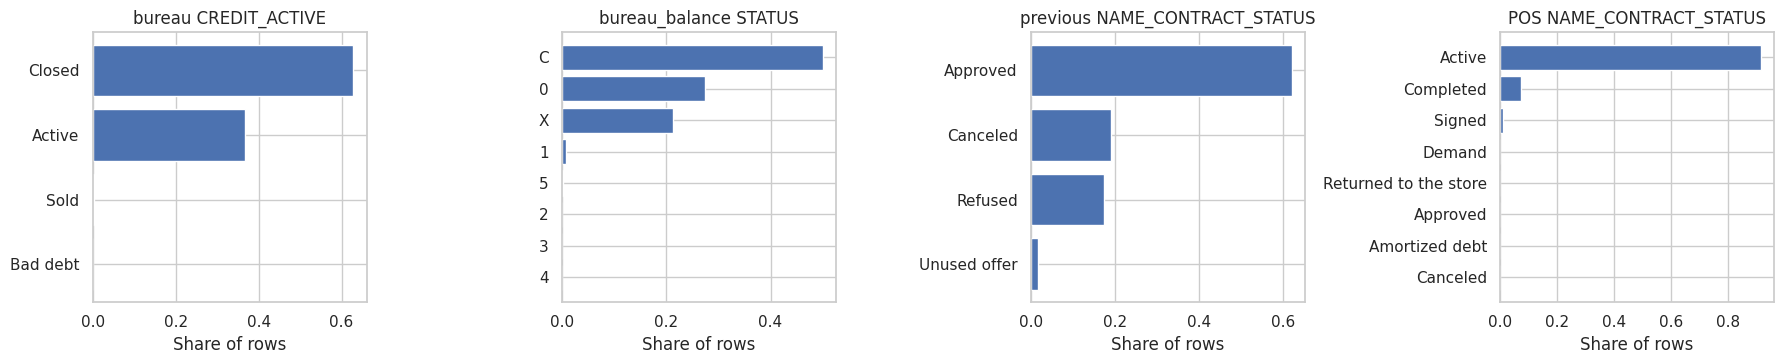

In [10]:
makeup = {
    "bureau CREDIT_ACTIVE": dfs["bureau"]["CREDIT_ACTIVE"],
    "bureau_balance STATUS": dfs["bureau_balance"]["STATUS"],
    "previous NAME_CONTRACT_STATUS": dfs["previous_application"]["NAME_CONTRACT_STATUS"],
    "POS NAME_CONTRACT_STATUS": dfs["POS_CASH_balance"]["NAME_CONTRACT_STATUS"],
}
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, (title, series) in zip(axes, makeup.items()):
    shares = series.value_counts(normalize=True).head(8)
    print(f"\n{title}\n{shares.round(4).to_string()}")
    ax.barh(shares.index.astype(str)[::-1], shares.values[::-1])
    ax.set_title(title)
    ax.set_xlabel("Share of rows")
fig.tight_layout()
save(fig, "08_history_makeup")

**Conclusion.** 62.9% of bureau loans are closed and 36.7% active; sold and bad-debt loans are rare. Monthly bureau statuses are mostly C (closed, 50.0%), 0 (no delay, 27.5%) and X (unknown, 21.3%), while the late statuses 1 to 5 together make up about 1.3% of months. Previous Home Credit applications were 62.1% approved, 18.9% canceled and 17.4% refused, and 91.5% of POS and cash rows are active months. This supports splitting bureau aggregates into active and closed loans, splitting previous applications into approved and refused, and treating any late bureau month as a rare and therefore informative event.

## How the history tables join to applicants

Aim: count how many applicants each history table covers and how many rows it holds per applicant. One-to-many joins must be aggregated to one row per applicant, and coverage tells us how often each feature group will be missing.

In [11]:
ids = app["SK_ID_CURR"]
rows = []
for name in ["bureau", "previous_application", "POS_CASH_balance", "credit_card_balance", "installments_payments"]:
    per = dfs[name].groupby("SK_ID_CURR").size()
    rows.append({"table": name, "applicants_covered_pct": round(100 * ids.isin(per.index).mean(), 1), "median_rows": float(per.median()), "max_rows": int(per.max())})
per_loan = dfs["bureau_balance"].groupby("SK_ID_BUREAU").size()
rows.append({"table": "bureau_balance per bureau loan", "applicants_covered_pct": np.nan, "median_rows": float(per_loan.median()), "max_rows": int(per_loan.max())})
cardinality = pd.DataFrame(rows).set_index("table")
print(cardinality.to_string())

                                applicants_covered_pct  median_rows  max_rows
table                                                                        
bureau                                            85.7          4.0       116
previous_application                              94.6          4.0        77
POS_CASH_balance                                  94.1         22.0       295
credit_card_balance                               28.3         22.0       192
installments_payments                             94.8         25.0       372
bureau_balance per bureau loan                     NaN         26.0        97


**Conclusion.** Coverage varies by table: 94.8% of applicants have instalment records, 94.6% previous applications and 94.1% POS and cash balances, but only 85.7% have bureau records and 28.3% credit card balances. A typical applicant has 4 bureau loans, 4 previous applications, 22 monthly POS or card balance rows and 25 instalment payments, with up to 372 instalment rows for one applicant. Every history table is one-to-many, so each must be aggregated to one row per applicant, and credit card features will be missing for most applicants.

## Early signal in credit history

Aim: test three simple history signals before engineering them properly: whether a bureau record exists, the number of refused previous applications, and the share of instalments paid late.


has_bureau
             count    mean
has_bureau                
False        44020  0.1012
True        263491  0.0773

refusal_band
               count    mean
refusal_band                
0             207217  0.0698
1              46534  0.0883
2-3            34598  0.1065
4+             19162  0.1334

late_band
            count    mean
late_band                
none       136644  0.0680
up to 5%    40212  0.0701
5-20%       77325  0.0940
over 20%    37462  0.1199


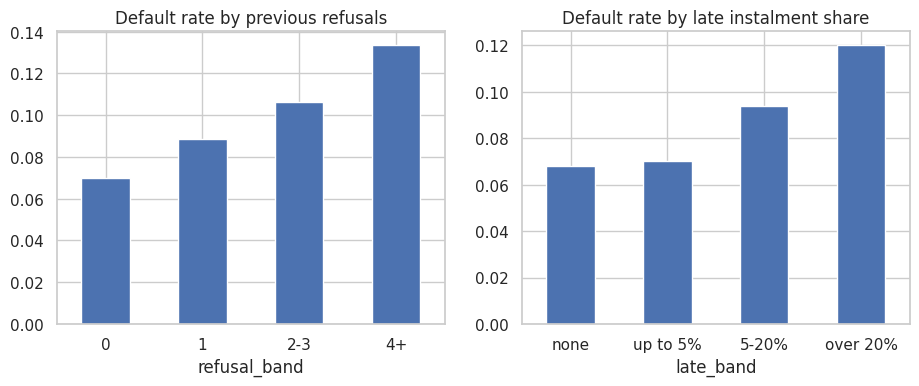

In [12]:
bureau_n = dfs["bureau"].groupby("SK_ID_CURR").size()
prev = dfs["previous_application"]
refused = prev[prev["NAME_CONTRACT_STATUS"] == "Refused"].groupby("SK_ID_CURR").size()
inst = dfs["installments_payments"]
late_share = (inst["DAYS_ENTRY_PAYMENT"] > inst["DAYS_INSTALMENT"]).groupby(inst["SK_ID_CURR"]).mean()
view = pd.DataFrame(
    {
        "TARGET": app["TARGET"].to_numpy(),
        "has_bureau": app["SK_ID_CURR"].map(bureau_n).notna().to_numpy(),
        "prev_refusals": app["SK_ID_CURR"].map(refused).fillna(0).to_numpy(),
        "late_share": app["SK_ID_CURR"].map(late_share).to_numpy(),
    }
)
view["refusal_band"] = pd.cut(view["prev_refusals"], [-1, 0, 1, 3, 10_000], labels=["0", "1", "2-3", "4+"])
view["late_band"] = pd.cut(view["late_share"], [-0.01, 0, 0.05, 0.2, 1.0], labels=["none", "up to 5%", "5-20%", "over 20%"])
for col in ["has_bureau", "refusal_band", "late_band"]:
    print(f"\n{col}\n{view.groupby(col, observed=True)['TARGET'].agg(['count', 'mean']).round(4).to_string()}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
view.groupby("refusal_band", observed=True)["TARGET"].mean().plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Default rate by previous refusals")
view.groupby("late_band", observed=True)["TARGET"].mean().plot.bar(ax=axes[1], rot=0)
axes[1].set_title("Default rate by late instalment share")
save(fig, "09_history_signals")

**Conclusion.** Even crude history signals separate risk. Applicants with no bureau record default at 10.12% against 7.73% for those with one. Default rises with the number of refused previous applications, from 6.98% with none to 13.34% with four or more, and with the share of late instalments, from 6.80% when none was late to 11.99% when more than 20% were. Notebook 2 builds these signals properly as refusal shares, late payment rates and the same measures over recent windows.

## Summary

- The population is 307,511 labelled applicants with an 8.07% default rate, so models are judged by AUC and related ranking metrics, never accuracy.
- The external scores are the strongest single signals but are incomplete, which motivates composite features (mean, minimum, maximum, product, weighted sum).
- `DAYS_EMPLOYED = 365243` marks 55,374 mostly retired applicants with a lower default rate; it becomes a missing value plus a flag.
- Amounts are skewed and cluster at round values, so ratios (credit to annuity, annuity to income, credit to goods price) become the main affordability features.
- All six scorecard segments show clearly different default rates, so the segment view in notebook 5 is meaningful.
- History tables are one-to-many with uneven coverage. Bureau loans split into active and closed, previous applications split into approved and refused, and late payment behaviour over recent windows are all aggregated per applicant in notebook 2.